/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


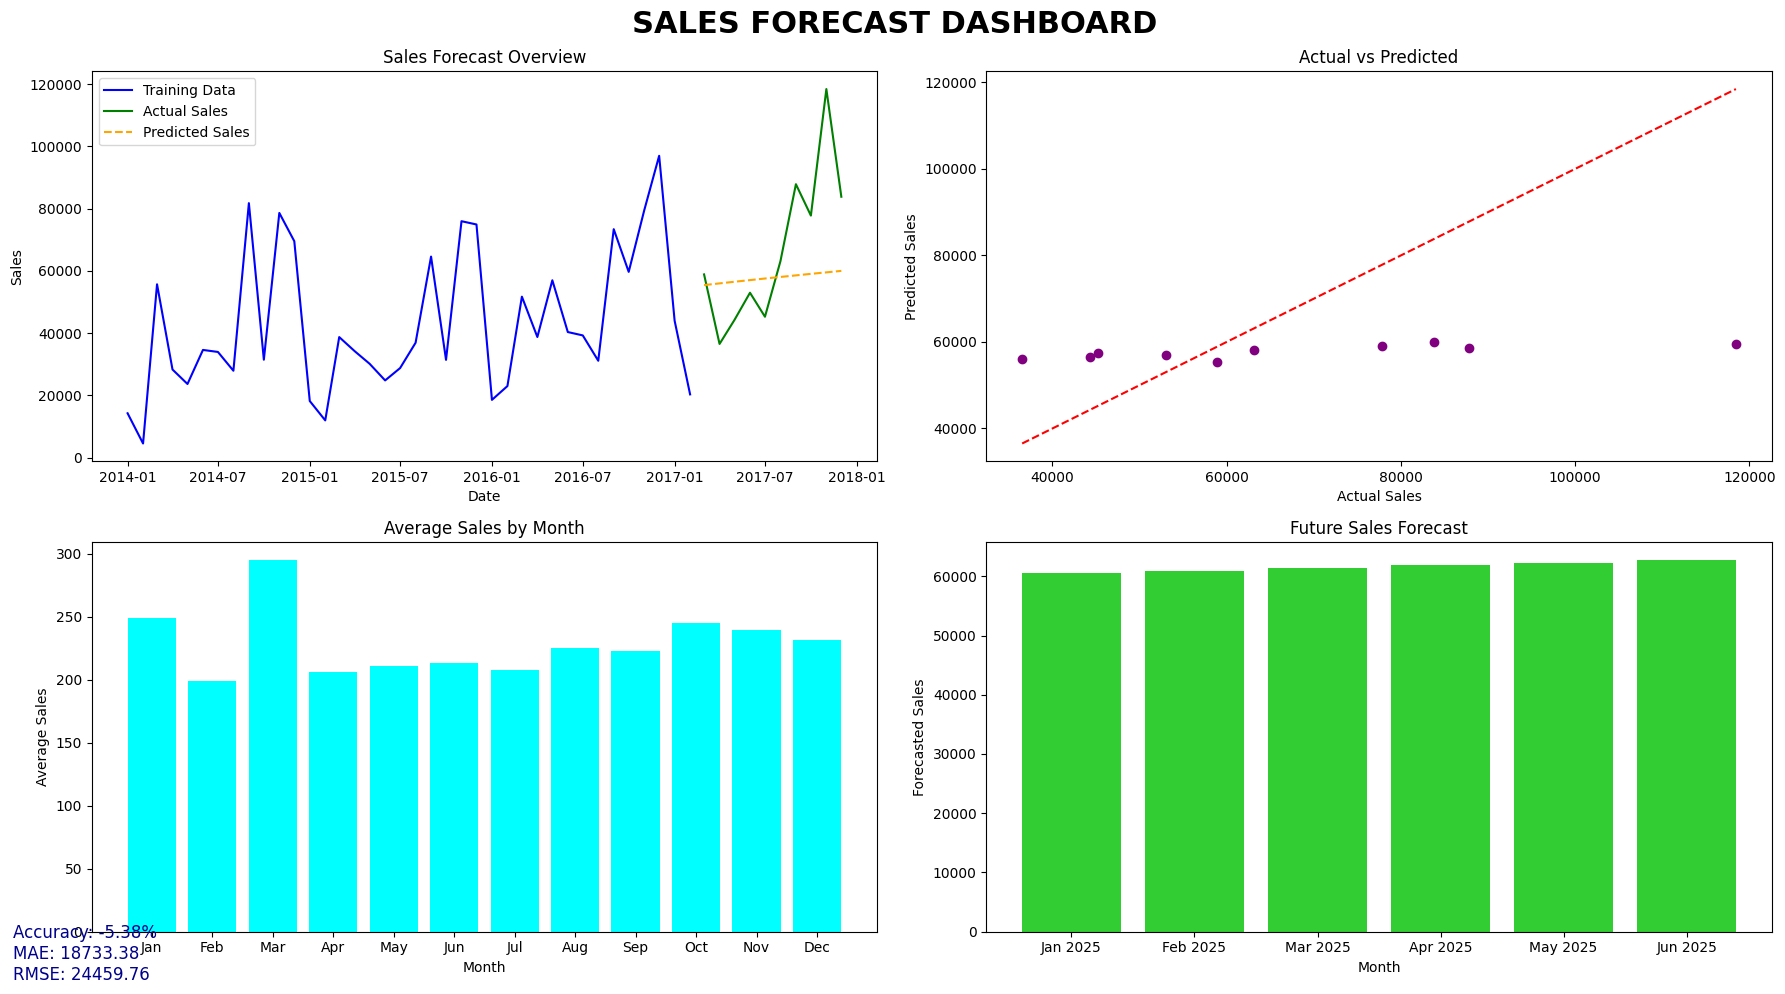

In [2]:
# ==========================================
# SALES FORECAST DASHBOARD
# ==========================================

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# ==========================================
# DATA PREPROCESSING
# ==========================================

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()

monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

monthly_sales['Month_Year'] = pd.to_datetime(
    monthly_sales['Month_Year']
)

monthly_sales['Month_Num'] = np.arange(len(monthly_sales))

# ==========================================
# MACHINE LEARNING
# ==========================================

X = monthly_sales[['Month_Num']]

y = monthly_sales['Sales']

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# TRAIN TEST SPLIT

train_size = int(len(X) * 0.8)

X_train = X_poly[:train_size]

X_test = X_poly[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

# TRAIN MODEL

model = LinearRegression()

model.fit(X_train, y_train)

# PREDICTIONS

predictions = model.predict(X_test)

# FUTURE FORECAST

future_months = np.arange(
    len(X),
    len(X) + 6
).reshape(-1,1)

future_poly = poly.transform(future_months)

future_forecast = model.predict(future_poly)

# ==========================================
# MODEL PERFORMANCE
# ==========================================

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

accuracy = r2 * 100

# ==========================================
# CREATE DASHBOARD
# ==========================================

fig = plt.figure(figsize=(18,10))

# ==========================================
# GRAPH 1 - SALES TREND
# ==========================================

ax1 = plt.subplot(2,2,1)

ax1.plot(
    monthly_sales['Month_Year'][:train_size],
    y_train,
    label='Training Data',
    color='blue'
)

ax1.plot(
    monthly_sales['Month_Year'][train_size:],
    y_test,
    label='Actual Sales',
    color='green'
)

ax1.plot(
    monthly_sales['Month_Year'][train_size:],
    predictions,
    label='Predicted Sales',
    color='orange',
    linestyle='dashed'
)

ax1.set_title("Sales Forecast Overview")

ax1.set_xlabel("Date")

ax1.set_ylabel("Sales")

ax1.legend()

# ==========================================
# GRAPH 2 - ACTUAL VS PREDICTED
# ==========================================

ax2 = plt.subplot(2,2,2)

ax2.scatter(
    y_test,
    predictions,
    color='purple'
)

ax2.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='dashed'
)

ax2.set_title("Actual vs Predicted")

ax2.set_xlabel("Actual Sales")

ax2.set_ylabel("Predicted Sales")

# ==========================================
# GRAPH 3 - MONTHLY SALES
# ==========================================

ax3 = plt.subplot(2,2,3)

monthly_avg = df.groupby('Month')['Sales'].mean()

months = [
    'Jan','Feb','Mar','Apr',
    'May','Jun','Jul','Aug',
    'Sep','Oct','Nov','Dec'
]

ax3.bar(
    months,
    monthly_avg,
    color='cyan'
)

ax3.set_title("Average Sales by Month")

ax3.set_xlabel("Month")

ax3.set_ylabel("Average Sales")

# ==========================================
# GRAPH 4 - FUTURE FORECAST
# ==========================================

ax4 = plt.subplot(2,2,4)

future_labels = [
    'Jan 2025',
    'Feb 2025',
    'Mar 2025',
    'Apr 2025',
    'May 2025',
    'Jun 2025'
]

ax4.bar(
    future_labels,
    future_forecast,
    color='limegreen'
)

ax4.set_title("Future Sales Forecast")

ax4.set_xlabel("Month")

ax4.set_ylabel("Forecasted Sales")

# ==========================================
# DASHBOARD TITLE
# ==========================================

plt.suptitle(
    "SALES FORECAST DASHBOARD",
    fontsize=22,
    fontweight='bold'
)

# ==========================================
# ADD METRICS TEXT
# ==========================================

plt.figtext(
    0.01,
    0.01,
    f'Accuracy: {accuracy:.2f}%\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}',
    fontsize=12,
    color='darkblue'
)

# ==========================================
# SAVE DASHBOARD
# ==========================================

plt.tight_layout()

plt.savefig(
    "sales_forecast_dashboard.png",
    dpi=300
)

# ==========================================
# SHOW DASHBOARD
# ==========================================

plt.show()